# Stochastic HJB Extension: Fundamental Risk and the LOB Shape Reversal

---

**Motivation.** The deterministic Bernoulli model (Part II of the main notebook) predicts a LOB shape $\mathcal{D}(a)$ that is *convex/decreasing* away from $a_{\min}$ — depth peaks near the minimum viable ask. Empirical Polymarket data shows the opposite: depth is *concave/increasing* toward the payout boundary at $a = 1$. This notebook resolves the discrepancy by introducing **fundamental risk** into the LP problem.

## §1. The Stochastic LP Problem

### New state variable: the fundamental $p_t$

The fundamental event probability follows a reflected diffusion on $[0,1]$:
$$dp_t = \sigma\, dW_t, \qquad p_t \in [0,1] \text{ (reflected)}.$$

The stationary distribution of this reflected Brownian motion is $\text{Uniform}[0,1]$.

### State-dependent execution flow

Buyer beliefs are anchored to the fundamental: a buyer with valuation $v = p + \epsilon$, $\epsilon \sim N(0, \gamma^2)$, buys at ask $a$ iff $v \ge a$. The execution flow becomes:

$$\phi(a, p) = \alpha\,\Phi\!\left(\frac{p - a}{\gamma}\right)$$

where $\Phi$ is the standard normal CDF and $\gamma$ controls buyer belief noise.

When $p \gg a$: everyone buys ($\phi \approx \alpha$). When $p \ll a$: no one buys ($\phi \approx 0$).

### Terminal payoff channel

At Poisson rate $\lambda$, the contract expires. The LP's position pays $(1-c)$ per share if the event occurs (probability $p$), or $(-c)$ if it fails. Expected terminal payoff per unit depth:

$$\lambda\bigl[p(1-c) + (1-p)(-c)\bigr] = \lambda(p - c).$$

This is the **risk channel**: near $p = 1$, the LP's inventory is safe; near $p = 0$, it's toxic.

## §2. The HJB Equation

The LP's value function $V(d, p;\, a)$ satisfies:

$$rV = (a-c)\mu(a,p)\,d - \mu(a,p)\,d\,V_d + \lambda(p-c)\,d + \tfrac{1}{2}\sigma^2 V_{pp}.$$

### Linear-in-$d$ reduction

Guess $V(d,p;a) = v(p;a) \cdot d$. Substituting and dividing by $d$:

$$\boxed{\frac{1}{2}\sigma^2 v''(p) - \bigl[r + \mu(a,p) + \lambda\bigr]\,v(p) = -(a-c)\,\mu(a,p) - \lambda(p-c)} \tag{Stochastic ODE}$$

with Neumann BCs $v'(0) = v'(1) = 0$ (reflected boundary).

This is a **second-order BVP in $p$** for each fixed $(a, r)$.

### Zero-volatility limit ($\sigma \to 0$)

When $\sigma = 0$, $v''$ drops out and we recover:
$$v_0(p;a) = \frac{(a-c)\mu(a,p) + \lambda(p-c)}{r + \mu(a,p) + \lambda}$$

which generalises the deterministic benchmark (with $\lambda = 0$ and $p$-independent $\phi$, this is the Bernoulli model value).

## §3. The Monotone Map Reversal

### Deterministic model: $a^*(r)$ increasing
- Spread $(a-c)$ is **certain profit** per fill
- More impatient LP $\Rightarrow$ wants wider spread $\Rightarrow$ posts higher $a$
- $a^*(r)$ is **increasing** in $r$

### Stochastic model: $a^*(r)$ decreasing
- High ask $\Rightarrow$ long wait for fills $\Rightarrow$ exposure to $p_t$ dropping
- Impatient LP ($r$ high) **cannot tolerate wait-risk** $\Rightarrow$ posts lower $a$ for quick fills
- Patient LP ($r$ low) **tolerates wait** $\Rightarrow$ posts high $a$ near the payout boundary
- $a^*(r)$ is **decreasing** in $r$

### Implication for LOB shape

If $G(r)$ has substantial mass at low $r$ (many patient LPs), depth accumulates at **high asks** near 1. This produces the **concave/increasing** LOB shape observed in Polymarket data.

---

# Implementation

In [1]:
import numpy as np
from scipy.linalg import solve_banded
from scipy.integrate import trapezoid
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12,
    'axes.labelsize': 14, 'axes.titlesize': 14,
    'legend.fontsize': 11, 'lines.linewidth': 2, 'figure.dpi': 120,
})

In [2]:
def phi_flow(a, p, alpha=10.0, gamma=0.05):
    """Execution flow: phi(a, p) = alpha * Phi((p-a)/gamma)."""
    return alpha * norm.cdf((p - a) / gamma)

def solve_v_bvp(a, r, D_a, sigma_v, c, lam, alpha_p=10.0, gamma_p=0.05, M_p=500):
    """Solve the stochastic ODE for v(p; a, r) via finite differences.
    
    (1/2) sigma^2 v'' - [r + mu(a,p) + lam] v = -(a-c)*mu(a,p) - lam*(p-c)
    Neumann BCs: v'(0) = v'(1) = 0.
    """
    p = np.linspace(0, 1, M_p + 1)
    h = p[1] - p[0]
    N = M_p + 1
    mu_grid = phi_flow(a, p, alpha_p, gamma_p) / max(D_a, 1e-10)
    s2h2 = 0.5 * sigma_v**2 / h**2
    
    main = np.zeros(N); rhs = np.zeros(N)
    sub_d = np.zeros(N); sup_d = np.zeros(N)
    
    for i in range(1, N-1):
        main[i] = -(2*s2h2 + r + mu_grid[i] + lam)
        sub_d[i] = s2h2; sup_d[i] = s2h2
        rhs[i] = -(a - c) * mu_grid[i] - lam * (p[i] - c)
    
    # Neumann BCs via ghost point method
    main[0] = -(2*s2h2 + r + mu_grid[0] + lam)
    sup_d[0] = 2*s2h2
    rhs[0] = -(a - c) * mu_grid[0] - lam * (p[0] - c)
    
    main[N-1] = -(2*s2h2 + r + mu_grid[N-1] + lam)
    sub_d[N-1] = 2*s2h2
    rhs[N-1] = -(a - c) * mu_grid[N-1] - lam * (p[N-1] - c)
    
    ab = np.zeros((3, N))
    ab[0, 1:] = [sup_d[i] for i in range(N-1)]
    ab[1, :] = main
    ab[2, :-1] = [sub_d[i+1] for i in range(N-1)]
    
    return p, solve_banded((1, 1), ab, rhs)

def expected_v(a, r, D_a, sigma_v, c, lam, alpha_p=10.0, gamma_p=0.05):
    """E_p[v(p; a)] averaged over stationary distribution (uniform)."""
    if a <= c + 0.001 or a >= 0.999:
        return -1e10
    p, v = solve_v_bvp(a, r, D_a, sigma_v, c, lam, alpha_p, gamma_p)
    return trapezoid(v, p)

print('Solver ready.')

Solver ready.


## §4. Risk Smoothing and Value Function

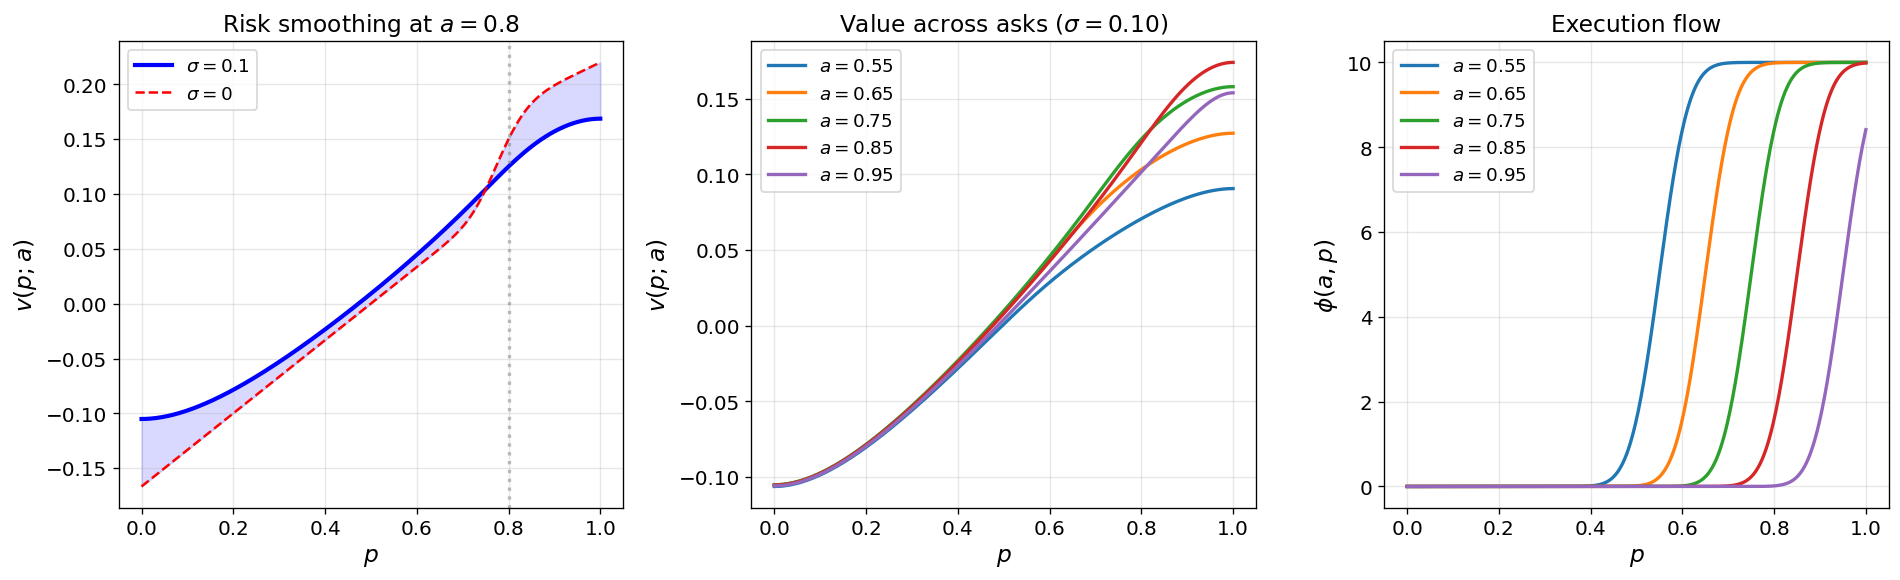

In [3]:
# Parameters
c_demo = 0.50; D_demo = 100; sigma_demo = 0.10; lam_demo = 0.05
p_g = np.linspace(0, 1, 501)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: v(p) stochastic vs deterministic
a_demo = 0.80
_, v_stoch = solve_v_bvp(a_demo, 0.10, D_demo, sigma_demo, c_demo, lam_demo)
mu_d = phi_flow(a_demo, p_g) / D_demo
v_det = ((a_demo-c_demo)*mu_d + lam_demo*(p_g-c_demo)) / (0.10+mu_d+lam_demo)

axes[0].plot(p_g, v_stoch, 'b-', lw=2.5, label=rf'$\sigma = {sigma_demo}$')
axes[0].plot(p_g, v_det, 'r--', lw=1.5, label=r'$\sigma = 0$')
axes[0].fill_between(p_g, v_det, v_stoch, alpha=0.15, color='blue')
axes[0].axvline(a_demo, color='gray', ls=':', alpha=0.5)
axes[0].set_xlabel('$p$'); axes[0].set_ylabel('$v(p; a)$')
axes[0].set_title(f'Risk smoothing at $a = {a_demo}$')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Panel 2: v(p; a) for multiple asks
for a_v in [0.55, 0.65, 0.75, 0.85, 0.95]:
    _, v_g = solve_v_bvp(a_v, 0.10, D_demo, sigma_demo, c_demo, lam_demo)
    axes[1].plot(p_g, v_g, lw=2, label=f'$a={a_v}$')
axes[1].set_xlabel('$p$'); axes[1].set_ylabel('$v(p; a)$')
axes[1].set_title(r'Value across asks ($\sigma=0.10$)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Panel 3: execution flow for reference
for a_v in [0.55, 0.65, 0.75, 0.85, 0.95]:
    axes[2].plot(p_g, phi_flow(a_v, p_g), lw=2, label=f'$a={a_v}$')
axes[2].set_xlabel('$p$'); axes[2].set_ylabel(r'$\phi(a, p)$')
axes[2].set_title('Execution flow'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## §5. Bertrand FOC and Monotone Map Reversal

r=0.05: a* = 0.829
r=0.50: a* = 0.765
r=2.00: a* = 0.753


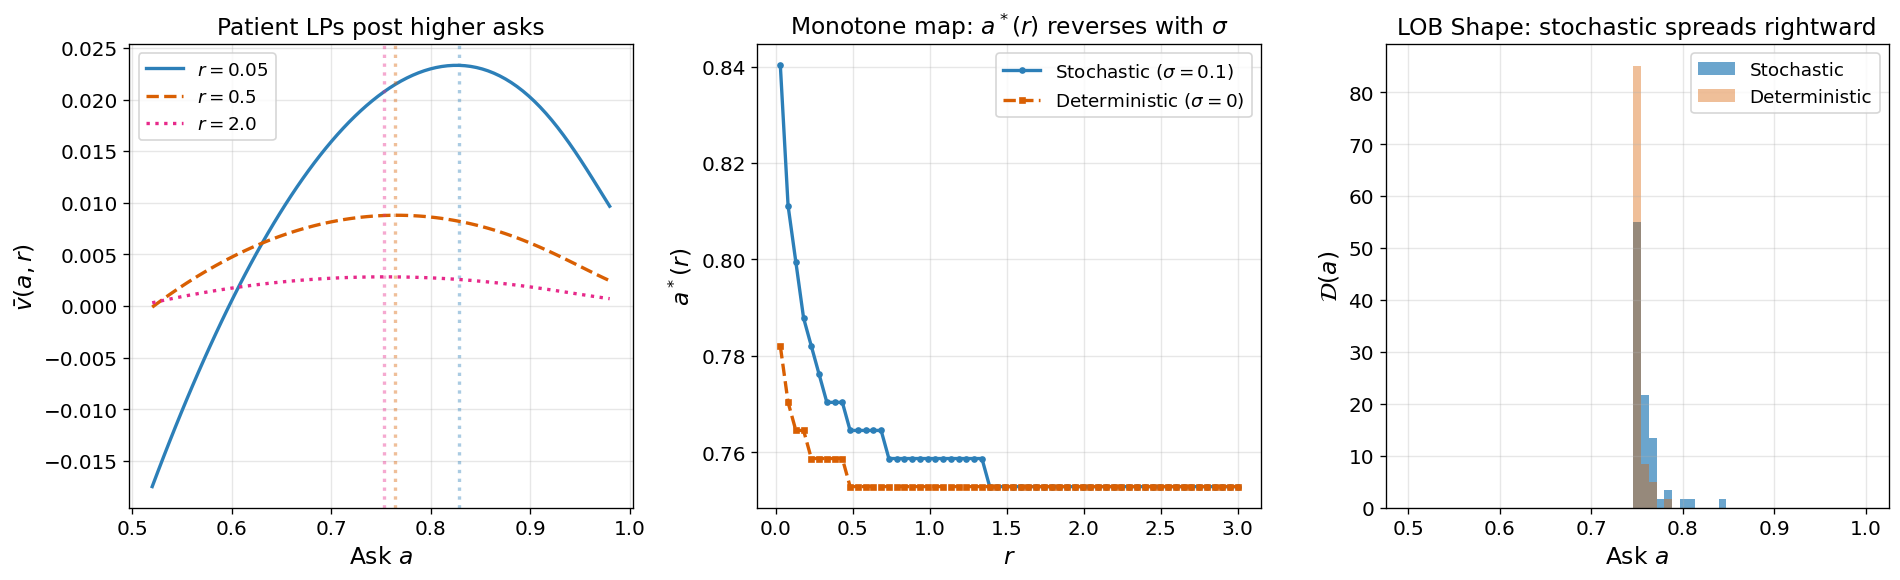

In [4]:
# E[v(a)] for patient vs impatient LPs
a_sw = np.linspace(c_demo + 0.02, 0.98, 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: E[v] vs a for different r
for r_val, col, ls in [(0.05, '#2c7fb8', '-'), (0.50, '#d95f02', '--'), (2.0, '#e7298a', ':')]:
    ev = [expected_v(a_v, r_val, D_demo, sigma_demo, c_demo, lam_demo) for a_v in a_sw]
    axes[0].plot(a_sw, ev, color=col, ls=ls, lw=2, label=f'$r={r_val}$')
    idx = np.argmax(ev)
    axes[0].axvline(a_sw[idx], color=col, ls=':', alpha=0.4)
    print(f'r={r_val:.2f}: a* = {a_sw[idx]:.3f}')

axes[0].set_xlabel('Ask $a$'); axes[0].set_ylabel(r'$\bar{v}(a, r)$')
axes[0].set_title('Patient LPs post higher asks')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Panel 2: a*(r) curve
r_fine = np.linspace(0.03, 3.0, 60)
a_star_stoch = np.zeros(len(r_fine))
a_star_det = np.zeros(len(r_fine))
for i, r_val in enumerate(r_fine):
    ev_s = [expected_v(a_v, r_val, D_demo, sigma_demo, c_demo, lam_demo) for a_v in a_sw]
    a_star_stoch[i] = a_sw[np.argmax(ev_s)]
    # Deterministic
    ev_d = []
    for a_v in a_sw:
        mu_avg = trapezoid(phi_flow(a_v, p_g), p_g) / D_demo
        ev_d.append(((a_v-c_demo)*mu_avg + lam_demo*(0.5-c_demo)) / (r_val+mu_avg+lam_demo))
    a_star_det[i] = a_sw[np.argmax(ev_d)]

axes[1].plot(r_fine, a_star_stoch, 'o-', color='#2c7fb8', ms=3, label=rf'Stochastic ($\sigma={sigma_demo}$)')
axes[1].plot(r_fine, a_star_det, 's--', color='#d95f02', ms=3, label=r'Deterministic ($\sigma=0$)')
axes[1].set_xlabel('$r$'); axes[1].set_ylabel('$a^*(r)$')
axes[1].set_title(r'Monotone map: $a^*(r)$ reverses with $\sigma$')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Panel 3: LOB shape comparison
N_LP = 100.0
a_bins = np.linspace(c_demo, 1.0, 60)
D_s, _ = np.histogram(a_star_stoch, bins=a_bins, weights=np.ones(len(r_fine))*N_LP/len(r_fine))
D_d, _ = np.histogram(a_star_det, bins=a_bins, weights=np.ones(len(r_fine))*N_LP/len(r_fine))
ac = 0.5*(a_bins[:-1]+a_bins[1:])

axes[2].bar(ac, D_s, width=a_bins[1]-a_bins[0], alpha=0.7, color='#2c7fb8', label='Stochastic')
axes[2].bar(ac, D_d, width=a_bins[1]-a_bins[0], alpha=0.4, color='#d95f02', label='Deterministic')
axes[2].set_xlabel('Ask $a$'); axes[2].set_ylabel(r'$\mathcal{D}(a)$')
axes[2].set_title('LOB Shape: stochastic spreads rightward')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## §6. Three Market Regimes

Computing Uncertain (c=0.2)...
  a* range: [0.6060, 0.7664]
Computing Mid-range (c=0.5)...
  a* range: [0.7545, 0.8493]
Computing Near-certain (c=0.95)...
  a* range: [0.9701, 0.9772]


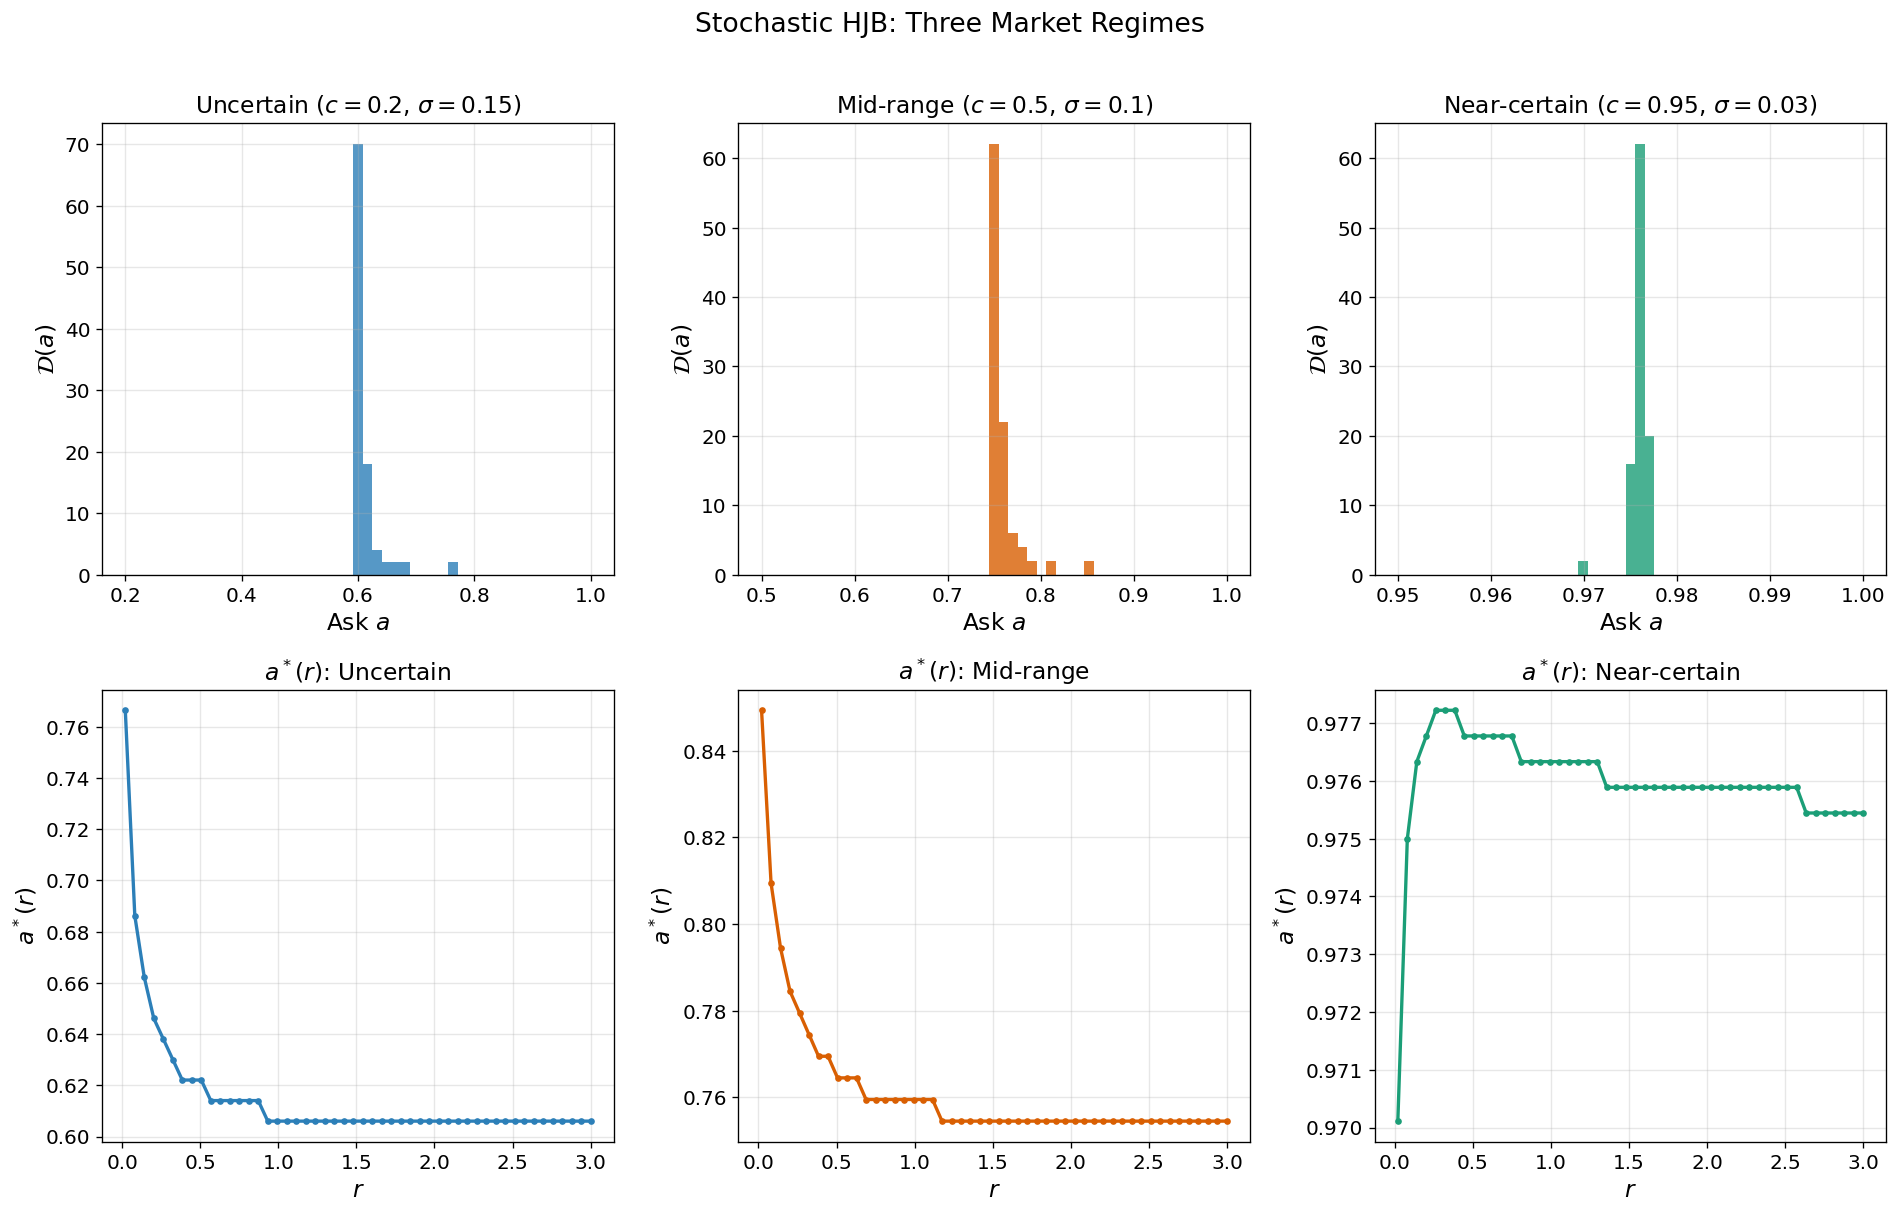

In [5]:
def compute_stoch_lob(c_p, sigma_p, gamma_p, lambda_p, alpha_p=10.0, D_a=100.0,
                       n_r=50, r_range=(0.02, 3.0), N_LP_p=100.0):
    """Compute LOB shape under the stochastic model."""
    r_g = np.linspace(r_range[0], r_range[1], n_r)
    a_sw = np.linspace(c_p + 0.005, 0.999, 100)
    a_star = np.zeros(n_r)
    for i, r_val in enumerate(r_g):
        ev = [expected_v(a_v, r_val, D_a, sigma_p, c_p, lambda_p, alpha_p, gamma_p)
              for a_v in a_sw]
        a_star[i] = a_sw[np.argmax(ev)]
    return r_g, a_star

configs = [
    ('Uncertain', 0.20, 0.15, 0.08, 0.03, '#2c7fb8'),
    ('Mid-range', 0.50, 0.10, 0.05, 0.05, '#d95f02'),
    ('Near-certain', 0.95, 0.03, 0.01, 0.10, '#1b9e77'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for j, (label, c_v, sig_v, gam_v, lam_v, col) in enumerate(configs):
    print(f'Computing {label} (c={c_v})...')
    r_g, a_star = compute_stoch_lob(c_v, sig_v, gam_v, lam_v)
    
    a_bins = np.linspace(c_v, 1.0, 50)
    D_h, be = np.histogram(a_star, bins=a_bins, weights=np.ones(len(r_g))*100/len(r_g))
    ac = 0.5*(be[:-1]+be[1:])
    
    axes[0,j].bar(ac, D_h, width=be[1]-be[0], color=col, alpha=0.8)
    axes[0,j].set_title(f'{label} ($c={c_v}$, $\\sigma={sig_v}$)')
    axes[0,j].set_xlabel('Ask $a$'); axes[0,j].set_ylabel(r'$\mathcal{D}(a)$')
    axes[0,j].grid(True, alpha=0.3)
    
    axes[1,j].plot(r_g, a_star, 'o-', color=col, ms=3)
    axes[1,j].set_xlabel('$r$'); axes[1,j].set_ylabel('$a^*(r)$')
    axes[1,j].set_title(f'$a^*(r)$: {label}')
    axes[1,j].grid(True, alpha=0.3)
    
    print(f'  a* range: [{a_star.min():.4f}, {a_star.max():.4f}]')

fig.suptitle('Stochastic HJB: Three Market Regimes', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

## §7. Volatility Comparative Static

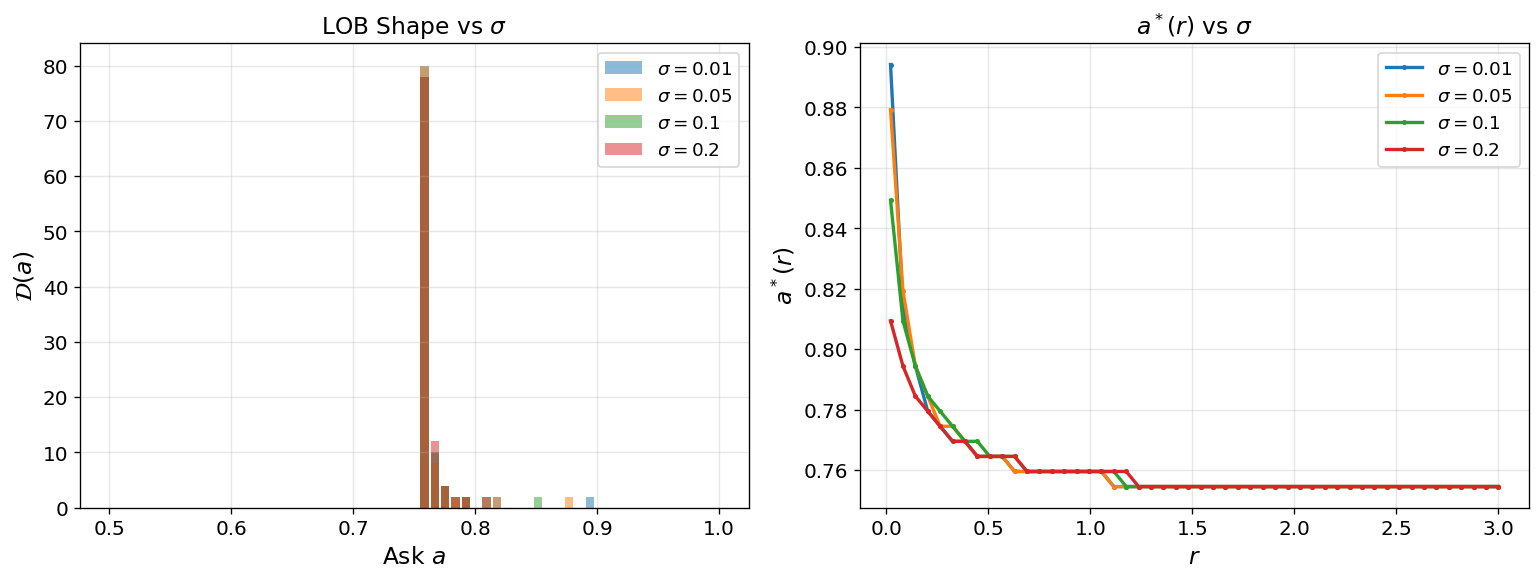

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
a_bins_cs = np.linspace(c_demo, 1.0, 60)
ac_cs = 0.5*(a_bins_cs[:-1]+a_bins_cs[1:])

for sigma_val in [0.01, 0.05, 0.10, 0.20]:
    r_g, a_star = compute_stoch_lob(c_demo, sigma_val, 0.05, lam_demo, n_r=50)
    D_h, _ = np.histogram(a_star, bins=a_bins_cs, weights=np.ones(len(r_g))*100/len(r_g))
    axes[0].bar(ac_cs, D_h, width=(a_bins_cs[1]-a_bins_cs[0])*0.8, alpha=0.5,
                label=rf'$\sigma={sigma_val}$')
    axes[1].plot(r_g, a_star, 'o-', ms=2, label=rf'$\sigma={sigma_val}$')

axes[0].set_xlabel('Ask $a$'); axes[0].set_ylabel(r'$\mathcal{D}(a)$')
axes[0].set_title(r'LOB Shape vs $\sigma$'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('$r$'); axes[1].set_ylabel('$a^*(r)$')
axes[1].set_title(r'$a^*(r)$ vs $\sigma$'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---

## §8. Summary and Connection to Main Model

### Key Result: Monotone Map Reversal

| | Deterministic ($\sigma = 0$) | Stochastic ($\sigma > 0$) |
|---|---|---|
| Impatient LP ($r$ high) | Posts wide (high $a$) | Posts tight (low $a$) |
| Patient LP ($r$ low) | Posts tight (low $a$) | Posts wide (high $a$) |
| $a^*(r)$ monotonicity | **Increasing** | **Decreasing** |
| LOB shape | Convex/decreasing | Concave/increasing |

### Economic Mechanism

The $\frac{1}{2}\sigma^2 v''$ term in the HJB introduces **wait-risk**: posting at a high ask means waiting longer for fills, during which $p_t$ can drop. Patient LPs tolerate this risk; impatient LPs don't. This flips the sorting of LPs across ask levels.

Near the payout boundary ($a \to 1$), the terminal payoff channel $\lambda(p - c)$ reinforces the effect: the contract is nearly certain to pay out, making high-$a$ positions safe. This creates a "risk shelter" that attracts patient capital.

### Relationship to Main Notebook

The deterministic Bernoulli model (§6–8 of the main notebook) is the **$\sigma \to 0$ limit** of the stochastic model. It captures the pure Bertrand sorting by impatience but misses the risk channel. The stochastic extension shows that fundamental risk qualitatively reverses the LOB shape prediction.

### Next Steps

1. **Self-consistent $\mathcal{D}(a)$**: Close the fixed-point by computing $D(a)$ and feeding it back into $\mu(a,p) = \phi(a,p)/\mathcal{D}(a)$.
2. **Calibrate to Polymarket**: Use observed LOB snapshots to pin down $\sigma$, $\gamma$, $\lambda$, and $G(r)$.
3. **Analytical characterisation**: Derive the stochastic Bertrand FOC in closed form for tractable $\phi$ specifications.
4. **Full MFG closure**: Embed in the Ma–Noh HJB–KFE framework with the stochastic fundamental as a common noise process.